# Etna: due metriche sismiche prima dell'inizio delle fasi eruttive

[![Apri in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Marco967a/Portfolio_Notebooks/blob/main/ETNA.ipynb)

**Domanda:** nei giorni prima dell'inizio di una fase eruttiva dell'Etna i terremoti hanno caratteristiche diverse dal normale?

Applichiamo **due metriche** scelte perché non dipendono dal *numero* di eventi (che varia con la rete di rilevazione):

1. **Profondità mediana** degli eventi negli ultimi 7 giorni (ipotesi: sismicità più superficiale prima dell'eruzione).
2. **b-value** (Gutenberg-Richter, Aki-Utsu) negli ultimi 90 giorni con magnitudo di completezza locale (ipotesi: variazione del rapporto tra eventi piccoli e grandi).

**Metodo:** test di permutazione. Si confronta il valore della metrica il giorno prima dell'inizio di ciascuna fase con quello di date di controllo "in quiete" (nessuna eruzione nei 30 giorni prima e dopo). Nessuna assunzione sulla distribuzione dei dati.

Dati: catalogo EtnaRCSC (INGV-OE, CC BY 4.0, DOI 10.13127/ETNASC/ETNARCSC) 2020 → feb 2026 e un elenco di eventi eruttivi compilato da bollettini INGV. Il notebook scarica tutto dal repository, non serve altro.

Codice della pipeline di raccolta dati (INGV, ISIDe, FIRMS, tremore) e analisi estese: [Etna_Data_Pipeline](https://github.com/Marco967a/Etna_Data_Pipeline).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

BASE = "https://raw.githubusercontent.com/Marco967a/Etna_Data_Pipeline/main/data_seed/"
START, PHASE_GAP, CTRL_GAP, N_NULL = "2021-01-01", 30, 30, 10000
rng = np.random.default_rng(42)

eq = pd.read_csv(BASE + "etnarcsc_2020_2026.csv", parse_dates=["event_time_utc"]).sort_values("event_time_utc")
ev = pd.concat([pd.read_csv(BASE + f) for f in ("eventi_noti_template.csv", "eventi_noti_2021_2026.csv")])
eruptions = pd.DatetimeIndex(pd.to_datetime(ev[ev.event_type.str.startswith("eruzione")].event_date).unique()).sort_values()
END = eq.event_time_utc.max().normalize()
print(f"{len(eq)} terremoti fino al {END.date()}; {len(eruptions)} giorni eruttivi")

7844 terremoti fino al 2026-02-28; 78 giorni eruttivi


## 1. Fasi eruttive indipendenti
Molti episodi (es. i parossismi del 2021) sono a pochi giorni l'uno dall'altro. Per non contare più volte lo stesso fenomeno, eruzioni separate da meno di 30 giorni sono una sola **fase**; si usa il **primo giorno** di ogni fase.

In [2]:
onsets = pd.DatetimeIndex([d for i, d in enumerate(eruptions)
                          if (i == 0 or (d - eruptions[i-1]).days > PHASE_GAP) and pd.Timestamp(START) <= d <= END])
print(len(onsets), "fasi:", ", ".join(d.strftime("%Y-%m-%d") for d in onsets))

14 fasi: 2021-01-19, 2021-05-19, 2021-10-23, 2021-12-16, 2022-02-10, 2023-05-21, 2023-08-14, 2023-11-12, 2024-07-04, 2024-11-10, 2025-02-08, 2025-06-02, 2025-08-14, 2025-12-24


## 2. Le due metriche, calcolate ogni giorno
Ogni valore usa solo terremoti **fino alla fine di quel giorno** (nessuna informazione dal futuro).

In [3]:
t = eq.event_time_utc.values.astype("datetime64[ns]")
mag, dep = eq.magnitude.to_numpy(float), eq.depth_km.to_numpy(float)
days = pd.date_range(pd.Timestamp(START) - pd.Timedelta(days=400), END - pd.Timedelta(days=1))

def b_value(m, mc, dm=0.1):
    m = m[m >= mc]
    return np.log10(np.e) / (m.mean() - (mc - dm / 2)) if len(m) else np.nan

def mc_maxc(m):                       # magnitudo di completezza: massima curvatura + 0.2
    return round(float(pd.Series(np.round(m, 1)).value_counts().idxmax()) + 0.2, 1)

depth7, b90 = [], []
for d in days:
    end = np.datetime64(d + pd.Timedelta(days=1))
    hi = np.searchsorted(t, end)
    lo7, lo90, lo365 = (np.searchsorted(t, end - np.timedelta64(w, "D")) for w in (7, 90, 365))
    depth7.append(np.median(dep[lo7:hi]) if hi - lo7 >= 5 else np.nan)
    if hi - lo365 >= 200:
        mc = mc_maxc(mag[lo365:hi]); m90 = mag[lo90:hi]
        b90.append(b_value(m90, mc) if (m90 >= mc).sum() >= 30 else np.nan)
    else:
        b90.append(np.nan)

F = pd.DataFrame({"depth_med_7d": depth7, "b_value_90d": b90}, index=days)
F.loc[START:].describe().round(2)

,depth_med_7d,b_value_90d
count,1757.00,1841.00
mean,6.49,1.18
std,3.84,0.21
min,-1.50,0.77
25%,4.30,1.05
50%,5.60,1.16
75%,7.40,1.30
max,27.20,2.23


## 3. Test di permutazione
- **Osservato:** media della metrica il giorno prima dell'inizio di ciascuna fase.
- **Null:** stessa media su altrettante date scelte a caso tra i giorni di quiete, ripetuto 10.000 volte.
- **Versione detrendata:** si sottrae la mediana mobile annuale della metrica, per togliere derive lente (cambi di rete, periodi di attività diversi).
- Il p-value è a due code. Con due metriche la soglia corretta (Bonferroni) è **0.025**.

In [4]:
er = eruptions.values.astype("datetime64[D]")
ok = np.array([not ((er >= d - CTRL_GAP) & (er <= d + CTRL_GAP)).any() for d in days.values.astype("datetime64[D]")])
pool_days = days[ok & (days >= START)]
detr = F - F.rolling(365, center=True, min_periods=120).median()

def perm_test(series):
    obs_vals = series.reindex(onsets - pd.Timedelta(days=1)).dropna().values
    pool = series.loc[pool_days].dropna().values
    obs = obs_vals.mean()
    null = np.array([rng.choice(pool, len(obs_vals)).mean() for _ in range(N_NULL)])
    p = (1 + (np.abs(null - null.mean()) >= abs(obs - null.mean())).sum()) / (N_NULL + 1)
    return dict(n_fasi=len(obs_vals), osservato=obs, controlli=null.mean(),
                percentile_null=(null < obs).mean() * 100, p_value=p), null, obs

rows, nulls = [], {}
for metric in F.columns:
    for version, D in (("grezza", F), ("detrendata", detr)):
        r, null, obs = perm_test(D[metric]); nulls[(metric, version)] = (null, obs)
        rows.append({"metrica": metric, "versione": version, **r})
res = pd.DataFrame(rows).round(3)
res["p<0.025 (senza correzione per selezione)"] = res.p_value < 0.025
res

,metrica,versione,n_fasi,osservato,controlli,percentile_null,p_value,p<0.025 (senza correzione per selezione)
0,depth_med_7d,grezza,13,4.338,6.455,0.16,0.021,True
1,depth_med_7d,detrendata,13,-1.167,0.926,0.23,0.022,True
2,b_value_90d,grezza,13,1.181,1.135,80.20,0.396,False
3,b_value_90d,detrendata,13,-0.011,-0.003,44.25,0.882,False


## 4. Grafici
**Sinistra/centro:** dove cade il valore osservato (linea rossa) rispetto alla distribuzione attesa per date casuali. **Destra:** andamento della profondità mediana attorno all'inizio delle fasi.

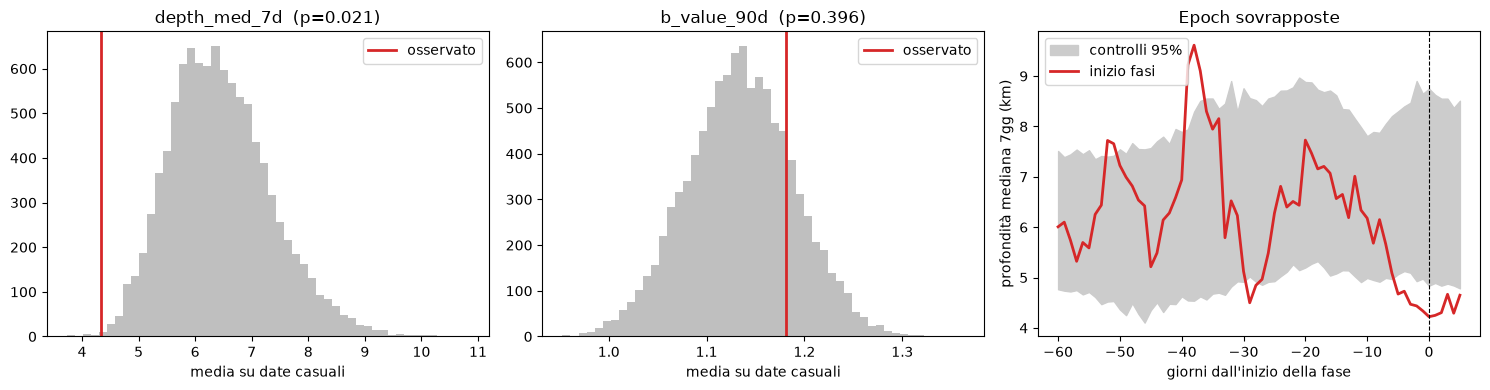

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, metric in zip(ax[:2], F.columns):
    null, obs = nulls[(metric, "grezza")]
    a.hist(null, bins=50, color="0.75"); a.axvline(obs, color="C3", lw=2, label="osservato")
    p = res[(res.metrica == metric) & (res.versione == "grezza")].p_value.iloc[0]
    a.set_title(f"{metric}  (p={p:.3f})"); a.set_xlabel("media su date casuali"); a.legend()
lags = np.arange(-60, 6)
curve = lambda dates: np.array([[F.depth_med_7d.get(d + pd.Timedelta(days=int(l)), np.nan) for l in lags] for d in dates])
null_c = np.array([np.nanmean(curve(rng.choice(pool_days, len(onsets))), axis=0) for _ in range(300)])
lo, hi = np.percentile(null_c, [2.5, 97.5], axis=0)
ax[2].fill_between(lags, lo, hi, color="0.8", label="controlli 95%")
ax[2].plot(lags, np.nanmean(curve(onsets), axis=0), color="C3", lw=2, label="inizio fasi")
ax[2].axvline(0, color="k", ls="--", lw=.8); ax[2].set_xlabel("giorni dall'inizio della fase")
ax[2].set_ylabel("profondità mediana 7gg (km)"); ax[2].legend(); ax[2].set_title("Epoch sovrapposte")
plt.tight_layout(); plt.show()

## 5. Coerenza tra le singole fasi
Il risultato medio può dipendere da poche fasi. Qui si guarda in quante fasi la metrica (detrendata) va nella stessa direzione.

In [6]:
from math import comb
for metric in F.columns:
    v = detr[metric].reindex(onsets - pd.Timedelta(days=1)).dropna()
    k, n = int((v < 0).sum()), len(v)
    p_sign = min(1, 2 * sum(comb(n, i) for i in range(min(k, n - k) + 1)) / 2**n)
    print(f"{metric:14s} sotto la norma in {k}/{n} fasi (sign test p={p_sign:.2f})")
    print("   valori per fase:", v.round(2).tolist())

depth_med_7d   sotto la norma in 10/13 fasi (sign test p=0.09)
   valori per fase: [-3.65, -0.1, -0.4, -0.75, -4.32, -0.1, 1.35, -2.3, -0.75, -5.5, -0.15, 0.7, 0.8]
b_value_90d    sotto la norma in 9/13 fasi (sign test p=0.27)
   valori per fase: [-0.2, -0.12, 0.34, -0.04, -0.12, -0.27, -0.01, -0.04, -0.03, 0.27, 0.01, 0.13, -0.07]


## 6. Controllo del confondente: perché non basta contare i terremoti
Il numero di eventi è la metrica più ovvia, ma dipende dalla rete di rilevazione e dal periodo: il 2021 ha molti più eventi registrati degli anni successivi. C'è anche un problema di **composizione dei controlli**: nel 2021 le eruzioni sono così frequenti che *nessun* giorno soddisfa il criterio di quiete (±30 giorni), quindi i controlli vengono solo dal 2022 in poi, mentre 4 inizi di fase su 14 cadono proprio nel 2021.

Verifichiamo il **conteggio negli ultimi 30 giorni** in tre versioni: grezza; con sottrazione della mediana annuale (toglie il livello ma non la scala); con il **logaritmo** meno la mediana annuale (toglie livello *e* scala).

In [7]:
daily_n = pd.Series(1.0, index=eq.event_time_utc.dt.normalize()).groupby(level=0).sum()
daily_n = daily_n.reindex(pd.date_range(days[0] - pd.Timedelta(days=30), END, freq="D"), fill_value=0)
n30 = daily_n.rolling(30).sum().reindex(days)
log_n = np.log10(n30.clip(lower=1))
versions = {"grezza": n30,
            "meno mediana annuale": n30 - n30.rolling(365, center=True, min_periods=120).median(),
            "log meno mediana annuale": log_n - log_n.rolling(365, center=True, min_periods=120).median()}
rows = []
for name, s in versions.items():
    r, _, _ = perm_test(s); rows.append({"versione": name, **r})
print("Inizi di fase per anno:", onsets.year.value_counts().sort_index().to_dict())
print("Giorni di controllo per anno:", pd.Series(pool_days.year).value_counts().sort_index().to_dict())
pd.DataFrame(rows).round(3)

Inizi di fase per anno: {2021: 4, 2022: 1, 2023: 3, 2024: 2, 2025: 4}
Giorni di controllo per anno: {2022: 283, 2023: 182, 2024: 203, 2025: 144, 2026: 35}


,versione,n_fasi,osservato,controlli,percentile_null,p_value
0,grezza,14,110.071,68.883,100.00,0.000
1,meno mediana annuale,14,23.643,2.125,99.75,0.003
2,log meno mediana annuale,14,0.050,-0.016,94.12,0.123


## 7. Conclusioni e come leggerle

| Metrica | Risultato | Lettura |
|---|---|---|
| Profondità mediana 7 gg | 4,3 km prima degli inizi di fase contro 6,5 km dei controlli (p ≈ 0.02, 13 fasi); coerente in 10 fasi su 13 | Sismicità più superficiale: ipotesi interessante, ma ottimistica (vedi sotto) |
| b-value 90 gg | Nessuna differenza (p ≈ 0.40) | Nessun segnale |
| Conteggio eventi 30 gg | 110 contro 69 eventi (p < 0.001) ma p ≈ 0.12 dopo aver tolto livello e scala | Artefatto di periodo e composizione dei controlli, non un precursore |

I p-value in tabella dicono se l'osservato è compatibile con date casuali.

**Attenzione alla selezione.** Le due metriche non sono state scelte a priori: la profondità mediana era la più promettente tra 54 test esplorativi (in quell'analisi nessuno era significativo dopo correzione per test multipli). Un p ≈ 0.02 su una metrica scelta *perché* era la migliore è **ottimistico**: la soglia Bonferroni a 2 test usata nella tabella non tiene conto di quella selezione. Il risultato va letto come una **ipotesi da confermare su altri dati**, non come evidenza di un precursore. La b-value non mostra nulla. **Un risultato non significativo non dimostra che il precursore non esista**: con soli 14 inizi di fase il test ha poca potenza e vede solo effetti grandi.

Limiti da tenere presenti:
- Gli eventi hanno solo la **data** (non l'ora): la "distanza" dall'inizio ha risoluzione di un giorno.
- L'elenco delle eruzioni non è esaustivo; per il 2021-2023 deriva da una compilazione secondaria dei comunicati INGV.
- Il catalogo EtnaRCSC si ferma a fine febbraio 2026: le eruzioni di giugno-agosto 2026 non sono incluse.
- Le due metriche sono state scelte dopo una esplorazione preliminare più ampia (54 test, nessuno significativo dopo correzione): trattare questi risultati come **verifica di un'ipotesi**, non come scoperta.
- I giorni di controllo provengono solo dal 2022 in poi (nel 2021 non c'è nessun giorno di quiete), mentre 4 inizi di fase su 14 sono del 2021: qualunque confronto è sensibile a differenze tra anni.
- Il catalogo copre un'area ampia (~10 km di distanza mediana dai crateri): la profondità mescola sismicità vulcanica e tettonica regionale.

Per approfondire: `reports/REPORT.md` nel repository, con l'analisi completa (tasso di sismicità, energia, modelli con validazione a blocchi).